## MAPPING TEMPERATURE TRENDS FOR ___
This project explores annual temperature trends for ___ over time, quantifying the rate of warming.




Import packages:

In [40]:
import pandas as pd # import pandas
import earthpy as et # import earthpy
import holoviews as hv #hv
import hvplot.pandas #hv for pandas?
hv.extension("bokeh")
import requests

import matplotlib.pyplot as plt # advanced options on matplotlib/seaborn/pandas plots
import seaborn as sns # SEABORN!!!!
from sklearn.linear_model import LinearRegression # fit an OLS linear regression

Importing data:

In [ ]:
'''rain_url = ("https://www.ncei.noaa.gov/pub/data/ghcn/daily/by_station/USC00456898.csv.gz")
d_rain_clim_df = pd.read_csv(url)
d_rain_clim_df.head()'''

/tmp/ipykernel_24912/2682512927.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  d_rain_clim_df = pd.read_csv(url)


,USC00456898,19161201,TMAX,6,Unnamed: 4,Unnamed: 5,6.1,Unnamed: 7
0,USC00456898,19161202,TMAX,17,NaN,NaN,6,NaN
1,USC00456898,19161203,TMAX,-22,NaN,NaN,6,NaN
2,USC00456898,19161204,TMAX,-39,NaN,NaN,6,NaN
3,USC00456898,19161205,TMAX,-44,NaN,NaN,6,NaN
4,USC00456898,19161206,TMAX,-22,NaN,NaN,6,NaN


Pretty messy, cleaning this up to be actually readable. Pulled from NOAA GHCN DAILY for USC00456898 (Mt Rainier Paradise Station)

See: https://www.ncei.noaa.gov/pub/data/cdo/documentation/GHCND_documentation.pdf

In [ ]:
'''# renaming columns to column names as in link above
d_rain_clim_df.columns = [
    "station",
    "date",
    "element",
    "value",
    "m_flag",
    "q_flag",
    "s_flag",
    "extra",
]

# converting units (credit to stackoverflow here)
d_rain_clim_df["date"] = pd.to_datetime(
    d_rain_clim_df["date"].astype(str),
    format="ISO8601"
)

# index by date so we can plot much easierly
d_rain_clim_df = d_rain_clim_df.set_index("date")

# temp stored in 1/10s of C
d_rain_clim_df["tempC"] = pd.to_numeric( # adding numeric to also get rid of errors
    d_rain_clim_df["value"],
    errors="coerce"
) / 10

d_rain_clim_df.head(10)'''

,station,element,value,m_flag,q_flag,s_flag,extra,tempC
date,,,,,,,,
1916-12-02,USC00456898,TMAX,17,NaN,NaN,6,NaN,1.7
1916-12-03,USC00456898,TMAX,-22,NaN,NaN,6,NaN,-2.2
1916-12-04,USC00456898,TMAX,-39,NaN,NaN,6,NaN,-3.9
1916-12-05,USC00456898,TMAX,-44,NaN,NaN,6,NaN,-4.4
1916-12-06,USC00456898,TMAX,-22,NaN,NaN,6,NaN,-2.2
1916-12-07,USC00456898,TMAX,-22,NaN,NaN,6,NaN,-2.2
1916-12-08,USC00456898,TMAX,-28,NaN,NaN,6,NaN,-2.8
1916-12-09,USC00456898,TMAX,-39,NaN,NaN,6,NaN,-3.9
1916-12-10,USC00456898,TMAX,-17,NaN,NaN,6,NaN,-1.7


Converting and plotting annual temperatures:

In [ ]:
'''rain_clim = d_rain_clim_df[['tempC']] # drop unused columns
#rain_clim

an_rain_clim = (rain_clim.resample('YS').mean()) # annual temps
an_rain_clim'''

,tempC
date,
1916-01-01,70.365584
1917-01-01,102.194786
1918-01-01,51.736993
1919-01-01,12.889199
1920-01-01,33.041598
...,...
2022-01-01,35.745710
2023-01-01,28.992797
2024-01-01,26.899532


PULLING FROM API INSTEAD TO FIX TEMP ISSUES
See: https://www.ncei.noaa.gov/support/access-data-service-api-user-documentation

In [30]:
rain_data = requests.get('https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&stations=USC00456898&startDate=1917-01-01&endDate=2026-01-01&format=json').json()
da_rain_clim = pd.DataFrame(rain_data)
da_rain_clim

,DATE,STATION,SNOW,TMAX,TMIN,TOBS,SNWD,PRCP,WT18,WT16,...,WT03,WT14,WT05,WT11,DAPR,MDPR,MDSF,DASF,WT09,WT06
0,1917-01-01,USC00456898,127,-17,-83,-28,4013,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1917-01-02,USC00456898,254,-6,-61,-33,4216,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1917-01-03,USC00456898,152,-17,-67,-33,4242,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1917-01-04,USC00456898,254,0,-33,-11,4369,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1917-01-05,USC00456898,406,0,-39,-39,4623,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36443,2025-12-28,USC00456898,0,-6,-94,-11,1295,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36444,2025-12-29,USC00456898,0,33,-28,33,1321,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36445,2025-12-30,USC00456898,0,117,33,67,1194,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36446,2025-12-31,USC00456898,0,111,56,67,1143,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


LET'S GO! Now we're going to fix the index (to datetime), drop many columns and get those annual averages to plot! (We could also have pulled annual from the api)

<Axes: xlabel='DATE'>

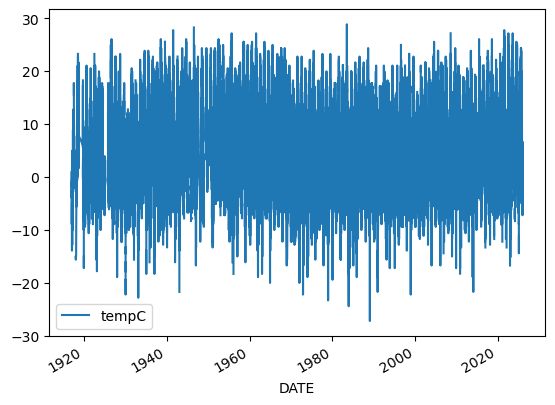

In [ ]:
# converting units (credit to stackoverflow here)
da_rain_clim["DATE"] = pd.to_datetime(
    da_rain_clim["DATE"].astype(str),
    format="ISO8601"
)

# index by date so we can plot much easierly
rain_clim_df = da_rain_clim.set_index("DATE")


rain_clim = rain_clim_df[['TOBS']] # drop unused columns
#rain_clim = rain_clim[['TOBS']]

rain_clim = rain_clim.rename(columns={
    'TOBS': 'tempC',
})


# temp stored in 1/10s of C
rain_clim["tempC"] = pd.to_numeric( # adding numeric to also get rid of errors
    rain_clim["tempC"],
    errors="coerce"
) / 10

# rain_clim.head(5)
rain_clim.plot()

<Axes: xlabel='DATE'>

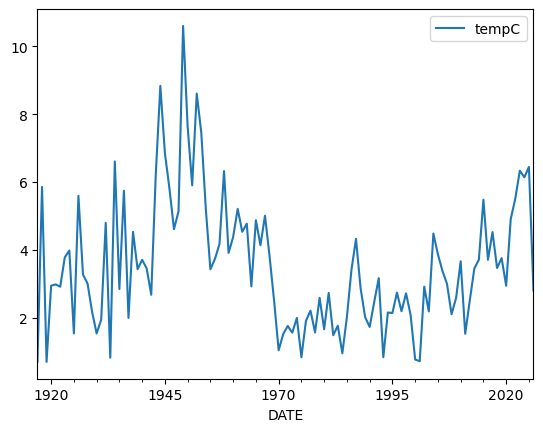

In [ ]:
# INFORMAL INFORMAL INFORMAL annual temp plot
an_rain_clim = (rain_clim.resample('YS').mean()) # annual temps
an_rain_clim.plot()

Interesting...


Plotting interactive plot

In [41]:
ann_clim_plot = an_rain_clim.hvplot(y = 'tempC', title = 'Annual Temperature (C) Average Mt Rainier Paradise Station', xlabel = 'Year', ylabel = 'Temperature (C)')
ann_clim_plot

:Curve   [DATE]   (tempC)